---------------------------

---

# 📊 Ders Notu: Büyük Veri Dünyasında Pandas vs. Spark

## 1. Temel Farklar ve Ölçeklenebilirlik
Veri işlemede iki ana yaklaşım vardır: **Dikey** ve **Yatay** ölçekleme.

* **Pandas (Dikey Ölçekleme):** Tek bir makine (single node) üzerinde çalışır. Performansı o makinenin **RAM kapasitesiyle** sınırlıdır.
* **Spark (Yatay Ölçekleme):** Birden fazla makineyi (cluster) birleştirerek çalışır. Performansı artırmak için daha pahalı bir makine almak yerine, sisteme **yeni makineler eklemek** yeterlidir.

| Özellik | Pandas | Spark |
| :--- | :--- | :--- |
| **Mimari** | Tek Makine | Dağıtılmış (Distributed) |
| **Hafıza Yönetimi** | Tek bir RAM | Kümedeki tüm RAM'lerin toplamı |
| **İşleme Kapasitesi** | Megabayt - Birkaç GB | Terabayt - Petabayt |
| **Kullanım Kolaylığı** | Çok yüksek (Sezgisel) | Orta (Planlama gerektirir) |



---

## 2. Büyük Veri Çözümleri: Hadoop vs. Spark
Büyük veri dendiğinde akla gelen iki dev isim arasındaki farklar şöyledir:

* **Hadoop:** Hesaplama sırasında ara verileri **diske yazar**. Bu yüzden daha az RAM gerektirir ancak daha **yavaştır**.
* **Spark:** Hesaplamaları doğrudan **bellekte (In-Memory)** yapar. Hadoop'tan çok daha **performanslıdır**.
* **PySpark:** Spark'ın Scala (JVM) ile yazılmış ana gövdesine Python ile erişmemizi sağlayan kütüphanedir.

---

## 3. Değerlendirme Stratejileri (Evaluation)
Verinin ne zaman ve nasıl işleneceğine dair iki farklı felsefe:

### A. İstekli (Eager) Değerlendirme - *Pandas Yaklaşımı*
Kodun her satırı çalıştırıldığı anda hesaplama yapılır.
* **Artısı:** Hata ayıklamak (debugging) çok kolaydır, sonuç anında görülür.
* **Eksisi:** Büyük veri setlerinde her adımda gereksiz kopyalar oluşturup sistemi yorar.

### B. Tembel (Lazy) Değerlendirme - *Spark Yaklaşımı*
İşlemler biriktirilir (istiflenir), ancak bir sonuç (Action) istenene kadar hesaplama başlatılmaz.
* **Artısı:** Spark, arka planda tüm adımları görür ve en verimli yolu (Execution Plan) çizer.
* **Eksisi:** Bir hata olduğunda, hatanın hangi adımda gerçekleştiğini bulmak daha zordur.



---

## 4. Pratik Limitler ve Seçim Kriterleri
Bir veri setinde ne zaman araç değiştirmeli?

* **0 - 5 GB:** Kesinlikle **Pandas**. Hızlı ve pratiktir.
* **5 - 100 GB:** **Pandas (Chunking)** veya **Dask**. Tek makinede sınırları zorlama aşaması.
* **100 GB + :** **Spark**. Dağıtılmış mimari artık bir zorunluluktur.

---

## 5. Teknik Zorluklar
* **Hata Mesajları:** PySpark hataları 3 katmanlıdır: Python İstisnası ➔ Çeviri Katmanı ➔ Scala/JVM Yığın İzi.
* **Stratejik Planlama:** Hangi komutların (örneğin `.show()`, `.count()`, `.collect()`) hesaplamayı tetikleyeceğini bilmek, performansı yönetmek için kritiktir.

---

## PYSPARK

#### Dask

In [2]:
import pandas as pd

In [3]:
import pandas as pd
import numpy as np   
import random

In [4]:
length=100000000    #``100 million rows, 2 columns olusturduk.
data={'a': (random.randint(0, 100) for _ in range(length)),
      'b': (random.randint(0, 100) for _ in range(length))}

In [5]:
df=pd.DataFrame(data)  #100 million rows, 2 columns olusturduk.Uzun surecektir.
df.head(5) 

,a,b
0,76,30
1,99,74
2,52,30
3,4,11
4,20,43


In [6]:
df.std()

a    29.153992
b    29.152264
dtype: float64

ayni islemleri ____DASK____ ile yapalim

In [7]:
import dask.dataframe as dd 

In [8]:
ddf=dd.from_pandas(df, npartitions=3)  #Dask dataframe'e cevirdik. Parcalara bolduk.
ddf

,a,b
npartitions=3,,
0,int64,int64
33333334,...,...
66666667,...,...
99999999,...,...


In [9]:
ddf.std()  #Ciktilari vermez. Ciktilari goruntulemek icin compute() fonksiyonunu kullanmamiz gerekiyor.

Dask Series Structure:
npartitions=1
a    float64
b        ...
Dask Name: sqrt, 4 expressions
Expr=MapPartitions(sqrt)

In [10]:
ddf.std().compute() #ciktilari goruntulemek icin compute() fonksiyonunu kullanmamiz gerekiyor.

a    29.153992
b    29.152264
dtype: float64

In [11]:
result=ddf.a.sum() - ddf.b.std() #Dask dataframe'de islemi yaparken sonucunu goruntulemek icin compute() fonksiyonunu kullanmamiz gerekiyor.
result

<dask_expr.expr.Scalar: expr=df['a'].sum() - MapPartitions(sqrt), dtype=float64>

In [12]:
result=ddf.a.sum() - ddf.b.std().compute() #a kolonunun toplamini hesapladik ve compute() ile sonucu goruntuleyebildik.
result.compute() #Sonucu goruntulemek icin compute() fonksiyonunu kullanmamiz gerekiyor

np.float64(4999983670.847735)

In [13]:
result.dask

{('sub-277db68fe7fd4cfd98de78ecc7bc7eeb',
  0): <Task ('sub-277db68fe7fd4cfd98de78ecc7bc7eeb', 0) sub(...)>,
 ('sum-tree-6af11edf4491ff23b9648e38c39d2ca8',
  0): (<function dask.utils.apply(func, args, kwargs=None)>,
  <bound method Reduction.aggregate of <class 'dask.dataframe.dask_expr._reductions.Sum'>>,
  [[('chunk-c54661c39fe5e9f19d02ca818762421f', 0),
    ('chunk-c54661c39fe5e9f19d02ca818762421f', 1),
    ('chunk-c54661c39fe5e9f19d02ca818762421f', 2)]],
  {'skipna': True, 'axis': 0}),
 ('chunk-c54661c39fe5e9f19d02ca818762421f',
  0): <Task ('chunk-c54661c39fe5e9f19d02ca818762421f', 0) chunk(..., ...)>,
 ('chunk-c54661c39fe5e9f19d02ca818762421f',
  1): <Task ('chunk-c54661c39fe5e9f19d02ca818762421f', 1) chunk(..., ...)>,
 ('chunk-c54661c39fe5e9f19d02ca818762421f',
  2): <Task ('chunk-c54661c39fe5e9f19d02ca818762421f', 2) chunk(..., ...)>,
 ('getitem-c57c1749dbaa17eb8334951540a315a9',
  0): <Task ('getitem-c57c1749dbaa17eb8334951540a315a9', 0) getitem(...)>,
 ('getitem-c57c1749dbaa

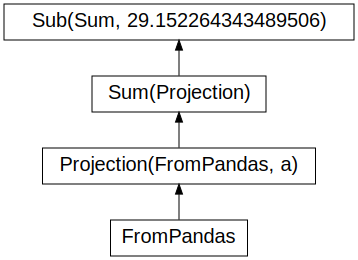

In [15]:
result.visualize()  #Dask'in islemi nasil parcalara boldugunu gorsellestirebiliriz.